# CRISP-DM na Prática: Previsão de Churn em Plataforma de Streaming

## Fase 2: Entendimento dos Dados

Nesta fase, exploramos o conjunto de dados para entender sua estrutura, qualidade e distribuição. Buscamos por valores faltantes, tipos de dados inconsistentes e a distribuição das variáveis.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent 
sys.path.append(str(ROOT))

In [2]:
#importando as bibliotecas
from data_understanding.download_data import download_file, return_data
from data_understanding.exploratory_data_analysis import generic_info, null_values, duplicated_values
from data_understanding.graphics_eda import bar_graph, hist_graph, dist_graph, correlation_multivariable, count_plot
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Download dos dados
download_file()

Download e extração concluídos!


In [4]:
# Leitura dos dados
df = return_data('contents/telecom_churn.csv')

df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


* verificando como os valores estão distribuídos e categorizados nas colunas

In [5]:
# avaliando as informações gerais do dataset

generic_info(df)

O dataset tem o shape de 3333 linhas e 11 colunas
--------------------------------------------------
As colunas  obtém os seguintes dados de máximo, mínimo e média:

Churn: (np.int64(0), np.int64(1)), 0.14491449144914492
AccountWeeks: (np.int64(1), np.int64(243)), 101.06480648064806
ContractRenewal: (np.int64(0), np.int64(1)), 0.903090309030903
DataPlan: (np.int64(0), np.int64(1)), 0.27662766276627665
DataUsage: (np.float64(0.0), np.float64(5.4)), 0.8164746474647464
CustServCalls: (np.int64(0), np.int64(9)), 1.5628562856285628
DayMins: (np.float64(0.0), np.float64(350.8)), 179.77509750975094
DayCalls: (np.int64(0), np.int64(165)), 100.43564356435644
MonthlyCharge: (np.float64(14.0), np.float64(111.3)), 56.3051605160516
OverageFee: (np.float64(0.0), np.float64(18.19)), 10.051488148814881
RoamMins: (np.float64(0.0), np.float64(20.0)), 10.237293729372938


* Temos:
  * 3333 linhas que podem ser lidas como clientes
  * Todas as colunas apresentam valores preenchidos variando entre os tipos inteiros e reais
  * Algumas colunas estão tratadas de forma numérica mas representam valores categóricos como o SIM ou NÃO (Churn, ContractTRenewal, DataPlan)

In [6]:
# checando a questão dos valores nulos
null_values(df)

Churn - Não existem valores nulos no dataset
AccountWeeks - Não existem valores nulos no dataset
ContractRenewal - Não existem valores nulos no dataset
DataPlan - Não existem valores nulos no dataset
DataUsage - Não existem valores nulos no dataset
CustServCalls - Não existem valores nulos no dataset
DayMins - Não existem valores nulos no dataset
DayCalls - Não existem valores nulos no dataset
MonthlyCharge - Não existem valores nulos no dataset
OverageFee - Não existem valores nulos no dataset
RoamMins - Não existem valores nulos no dataset


In [7]:
# verificando se existem valores duplicados
duplicated_values(df)

'Existem 0 valores duplicados no dataset'

In [8]:
df.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


É possível observar que há uma diferença em relação ao intervalo encontrado nas features. Isso indica a necessidade de normalização.

## Gráficos

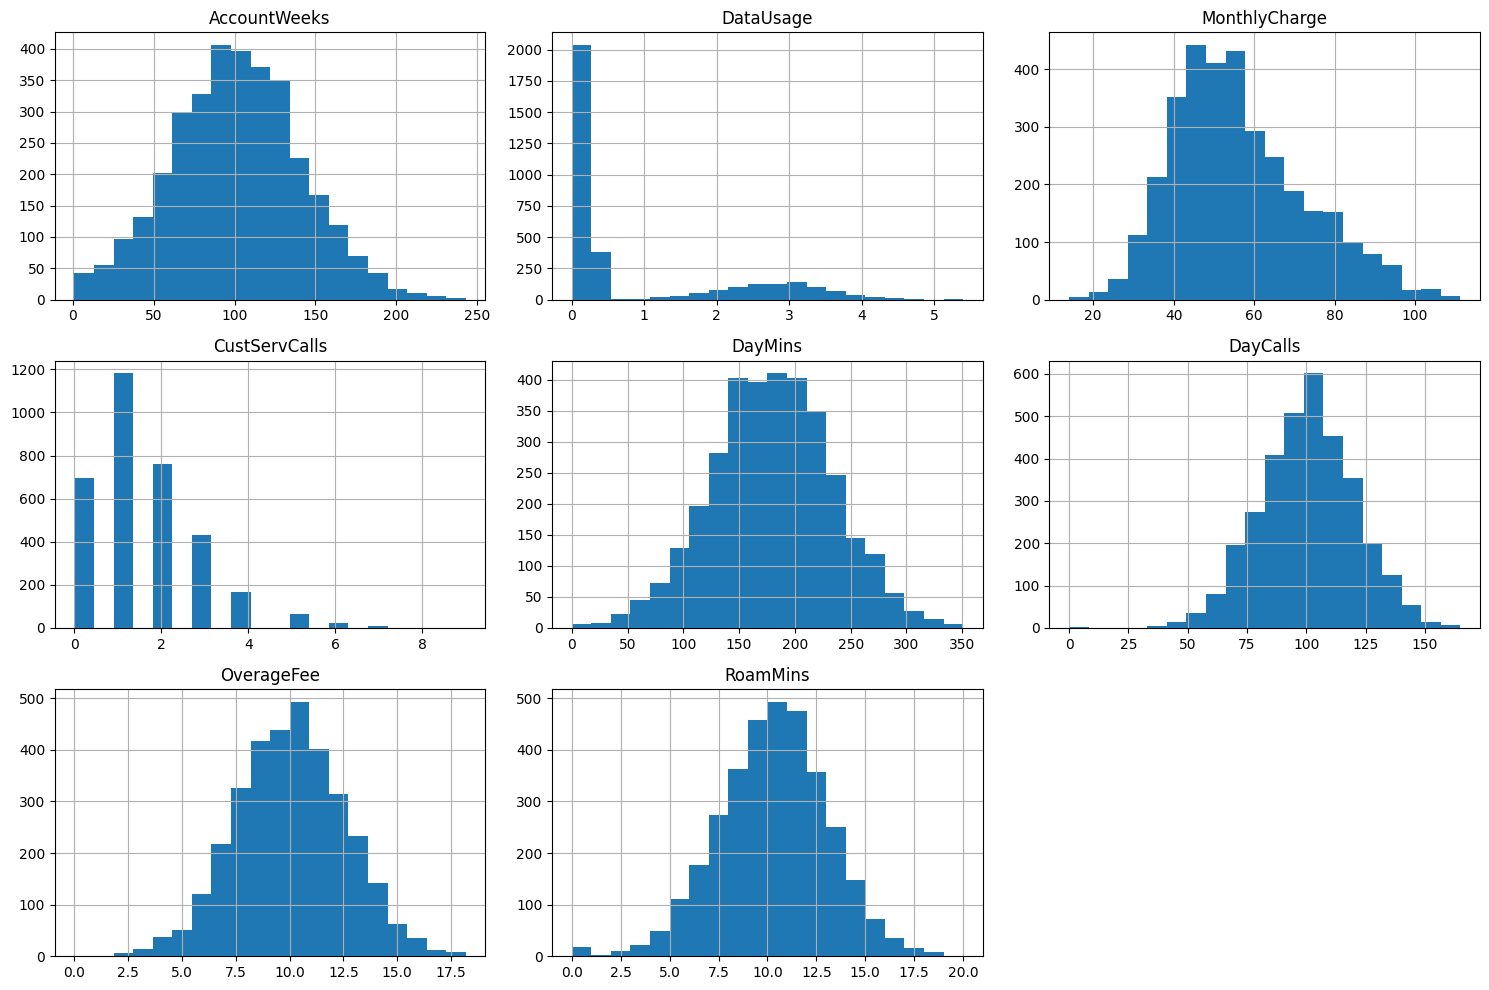

In [9]:
dist_graph(df,['AccountWeeks','DataUsage','MonthlyCharge','CustServCalls','DayMins','DayCalls','OverageFee','RoamMins'])
plt.show()

Observações:
  1. Podemos observar que a maioria dos dados apresentam uma distribuição aproximadamente normal. Isto indica que iremos padronizá-los.
  2. Para a feature de data usage vemos que a quantidade de dados utilizados se concentra mais no intervalo de 0 a 0.5 GB. Ou seja, não há tanto uso de dados nestes clientes podendo ser uma parcela a ser investigada.

* Analisando o perfil do usuário sobre o churn

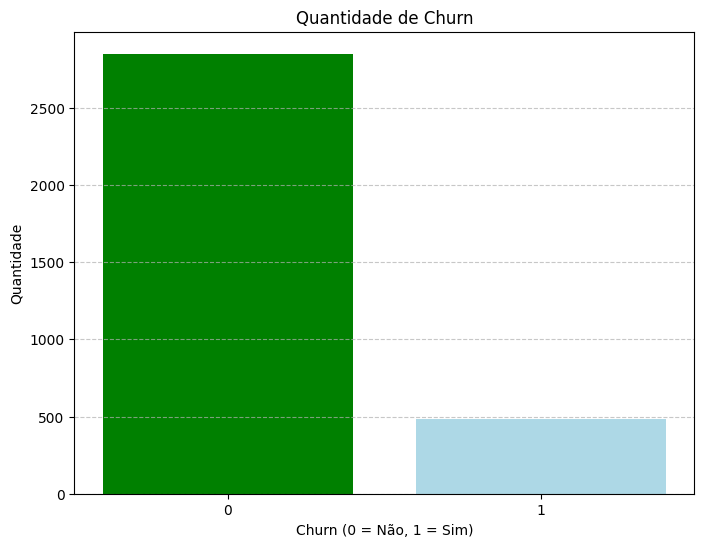

In [10]:
bar_graph(df,'Churn')
plt.show()

Existem muitos mais casos sem churn. Ou seja, os dados estão desbalanceados e irá influenciar no treinamento do modelo.

In [11]:
# Grupo de pessoas a partir da renovação de contrato recente
df_vis_churn = df.groupby(['ContractRenewal','Churn'])['Churn'].count()
df_vis_churn

ContractRenewal  Churn
0                0         186
                 1         137
1                0        2664
                 1         346
Name: Churn, dtype: int64

A quantidade de pessoas que fizeram uma renovação recente e efetuaram o churn é bem maior do que as pessoas que não renovaram recentemente. Isto pode indicar que talvez após a renovação possa ter ocorrido algum fator que influenciou a saída, por exemplo, o aumento da fatura.

In [12]:
# Grupo de pessoas com plano de dados
df_vis_churn = df.groupby(['DataPlan','Churn'])['Churn'].count()
df_vis_churn

DataPlan  Churn
0         0        2008
          1         403
1         0         842
          1          80
Name: Churn, dtype: int64

As pessoas sem plano de dados efetuam mais o churn do que as pessoas com plano de dados. Ou seja, indica que talvez a medida que o uso de dados vá aumentando e não há um plano que cubra este consumo, o que está relacionado a fatura ou disponibilidade dos dados, as pessoas vão efetuando a saída da base.

In [13]:
# Analisando as classificações de renovação de contrato, plano de dados e churn ao mesmo tempo

# dataplan -> 0 = não, 1 = sim
# contractrenewal -> 0 = não, 1 = sim
# churn -> 0 = não, 1 = sim

df_vis_churn = df.groupby(['ContractRenewal','DataPlan','Churn'])['Churn'].count()
df_vis_churn

ContractRenewal  DataPlan  Churn
0                0         0         130
                           1         101
                 1         0          56
                           1          36
1                0         0        1878
                           1         302
                 1         0         786
                           1          44
Name: Churn, dtype: int64

Analisando a intersecção entre os conjuntos de renovação de contrato, churn e plano de dados

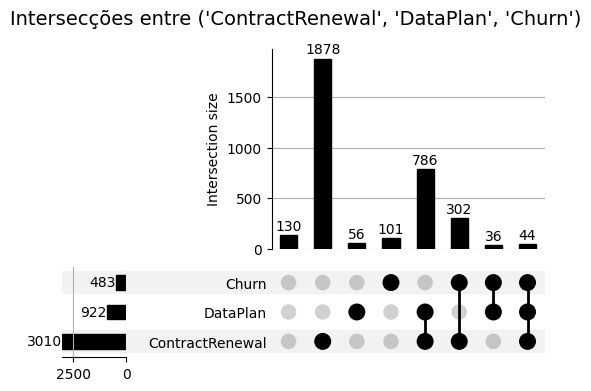

In [14]:
correlation_multivariable(df,['ContractRenewal', 'DataPlan', 'Churn'])
plt.show()

A maioria da base renovou o contrato (3010 clientes)

Mesmo renovando contrato:

  * 302 efetuaram o churn sem plano de dados
  * 44 efetuaram o churn mesmo com plano de dados. O que chama atenção, pois este grupo, teoricamente, já recebeu dois incentivos de retenção mas mesmo assim saiu do contrato.

Clientes sem renovação têm churn relativamente alto (101 + 36)

* Analises complementares

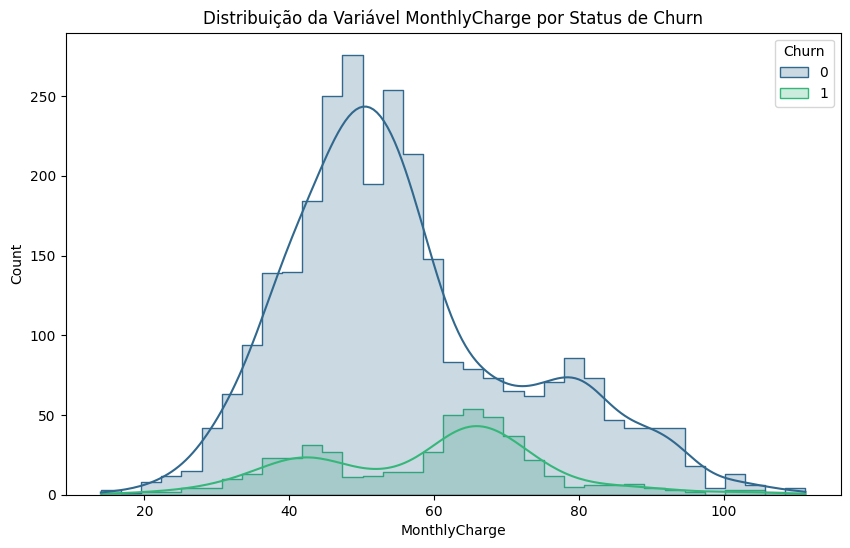

In [15]:
# Analisando a hipótese se o valor da fatura tem algum impacto no churn
hist_graph(df,'MonthlyCharge','Churn')
plt.show()

Temos uma concentração maior de churn no intervalo de fatura entre 60 a 80. Algo que não é visto se compararmos com o grupo sem churn que se concentra entre 40 a 60 em termos de fatura.

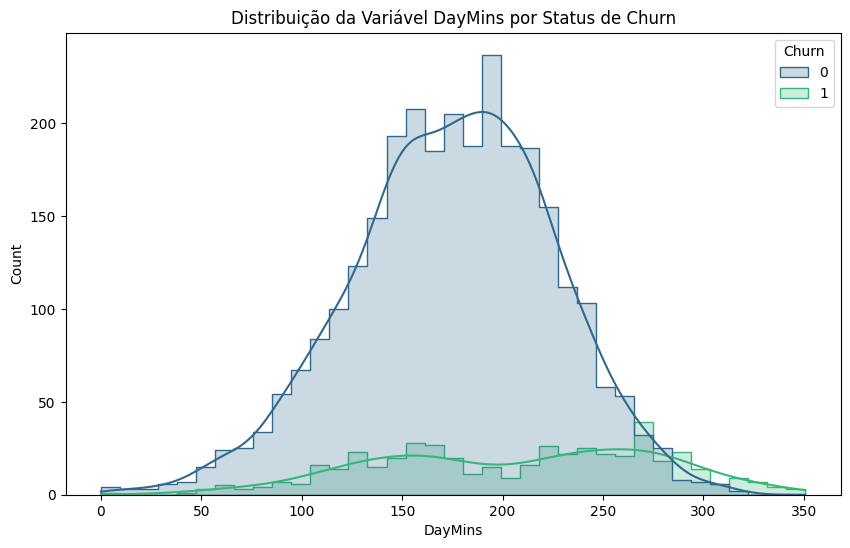

In [16]:
# Verificando a relação do uso de minutos
hist_graph(df,'DayMins','Churn')
plt.show()

É possível observar que há uma concentração maior em relação a média de minutos dos clientes que efetuaram churn nos valores acima de 200.

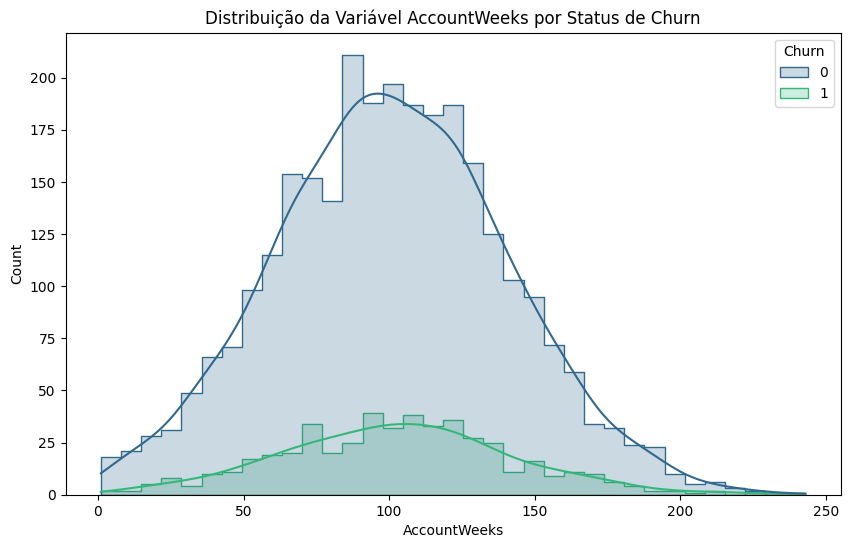

In [17]:
# Verificando a relação da quantidade de semanas ativas e o 
hist_graph(df,'AccountWeeks','Churn')
plt.show()

Os usuários que efetuam churn estão concentrados no intervalo de 50 a 150 semanas ativas.

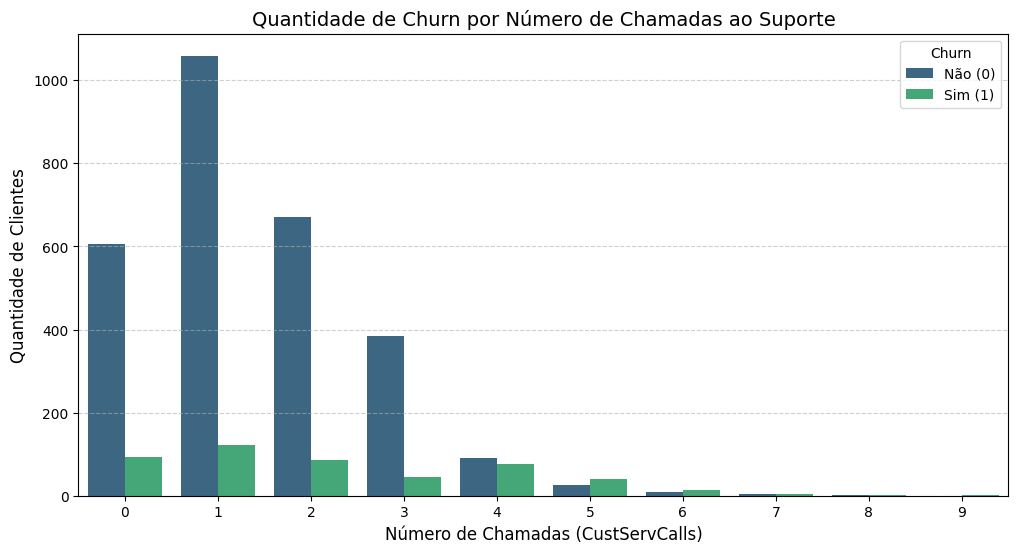

In [18]:
# Analisando a quantidade de chamadas efetuadas ao suporte e o status de churn
count_plot(df,'CustServCalls','Churn')
plt.show()

As pessoas que realizam o cancelamento efetuam mais ligações acima de 4 vezes. Talvez, elas não estão conseguindo solucionar algum tipo de problema e por ter tentado mais de 4 vezes resolvem desistir do contrato.